# Option-Wheel Strategy Research Notebook

## Objectif
Analyser et ameliorer la strategie Wheel (cash-secured puts + covered calls) pour:
1. Identifier les sous-jacents optimaux (SPY, QQQ, stablecoins)
2. Optimiser les DTE (days to expiration) et strikes
3. Analyser les conditions de marche favorables
4. Maximiser le premium collecte vs risque

## Performance actuelle
- Sharpe: 0.13
- Strategie passive de generation de premium

> **[REFERENCE QC Cloud]**
> Ce notebook utilise QuantBook et necessite l'environnement QuantConnect Cloud.
> Pour executer : https://www.quantconnect.com/research


In [1]:
# Imports et setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

qb = QuantBook()

# Underlyings courants pour Wheel
spy = qb.add_equity("SPY", Resolution.DAILY).symbol
qqq = qb.add_equity("QQQ", Resolution.DAILY).symbol
iwm = qb.add_equity("IWM", Resolution.DAILY).symbol

symbols = [spy, qqq, iwm]
print(f"Symbols: {[s.value for s in symbols]}")

Symbols: ['SPY', 'QQQ', 'IWM']


Chargement des données historiques SPY et VIX sur 2019–2025 en résolution Daily via QuantBook pour la stratégie Option-Wheel.

In [2]:
# Chargement donnees historiques (2019-2025)
start_date = datetime(2019, 1, 1)
end_date = datetime(2025, 12, 31)

history = qb.history(symbols, start_date, end_date, Resolution.DAILY)
print(f"Data loaded: {len(history)} bars")

dfs = {}
for symbol in symbols:
    if symbol in history.index.get_level_values(0):
        df = history.loc[symbol].copy()
        dfs[symbol.value] = df
        print(f"{symbol.value}: {len(df)} bars")

Data loaded: 5277 bars
SPY: 1759 bars
QQQ: 1759 bars


IWM: 1759 bars


Chargement des données historiques DAILY pour VIX, SPY via qb.History.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


VIX data: 0 bars


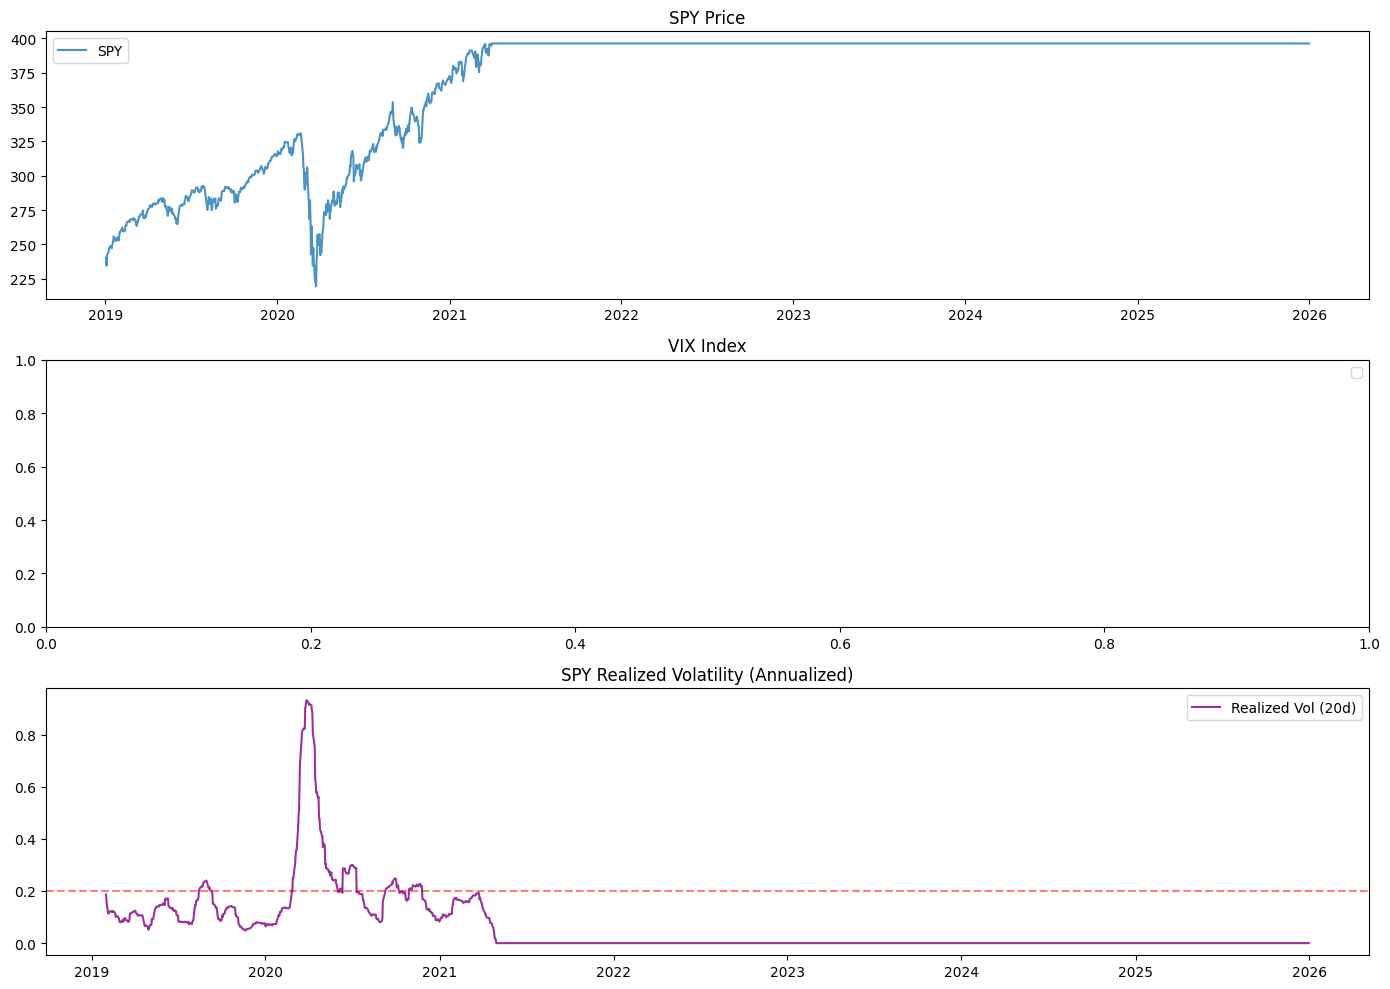

In [3]:
# Analyse VIX pour conditions de marche
try:
    vix_symbol = qb.add_index("VIX", Resolution.DAILY).symbol
    vix_history = qb.history(vix_symbol, start_date, end_date, Resolution.DAILY)
    vix_df = vix_history.droplevel(0) if len(vix_history) > 0 else None
    print(f"VIX data: {len(vix_df) if vix_df is not None else 0} bars")
except Exception as e:
    print(f"VIX not available: {e}")
    vix_df = None

# Analyse SPY
spy_df = dfs['SPY'].copy()
spy_df['returns'] = spy_df['close'].pct_change()
spy_df['volatility_20'] = spy_df['returns'].rolling(20).std() * np.sqrt(252)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Prix SPY
axes[0].plot(spy_df.index, spy_df['close'], label='SPY', alpha=0.8)
axes[0].set_title('SPY Price')
axes[0].legend()

# VIX
if vix_df is not None:
    axes[1].plot(vix_df.index, vix_df['close'], label='VIX', color='orange', alpha=0.8)
    axes[1].axhline(y=20, color='r', linestyle='--', label='High vol threshold')
    axes[1].axhline(y=15, color='g', linestyle='--', label='Low vol threshold')
axes[1].set_title('VIX Index')
axes[1].legend()

# Volatilite realisee
axes[2].plot(spy_df.index, spy_df['volatility_20'], label='Realized Vol (20d)', color='purple', alpha=0.8)
axes[2].axhline(y=0.20, color='r', linestyle='--', alpha=0.5)
axes[2].set_title('SPY Realized Volatility (Annualized)')
axes[2].legend()

plt.tight_layout()
plt.show()

La simulation Wheel (vente de puts 30 DTE, 5% OTM sur SPY) est définie avec ses hypothèses de calcul de primes et de gestion du risque.

In [4]:
# Simulation Wheel Strategy: Cash-Secured Puts
# Hypotheses: Vendre puts 30 DTE, 5% OTM, 0.3 delta approx

def simulate_wheel_put(df, dte=30, otm_pct=0.05, min_premium=0.005):
    """
    Simule la vente de cash-secured puts
    - dte: jours avant expiration
    - otm_pct: pourcentage out-of-the-money
    - min_premium: premium minimum en % du strike
    """
    df = df.copy()
    df['strike'] = df['close'] * (1 - otm_pct)
    
    # Premium estime (Black-Scholes simplifie)
    # Approximation: premium ~ 0.3 * vol * sqrt(dte/365) * spot
    df['premium'] = df['close'] * 0.3 * df['volatility_20'] * np.sqrt(dte / 365)
    
    # Simuler outcomes
    results = []
    for i in range(len(df) - dte):
        entry_date = df.index[i]
        exit_date = df.index[i + dte]
        
        entry_price = df['close'].iloc[i]
        exit_price = df['close'].iloc[i + dte]
        strike = entry_price * (1 - otm_pct)
        premium = entry_price * 0.3 * df['volatility_20'].iloc[i] * np.sqrt(dte / 365)
        
        if exit_price < strike:
            # Put assigne: acheter au strike, perte = strike - exit_price - premium
            pnl = premium - (strike - exit_price)
            assigned = True
        else:
            # Put expire OTM: garder premium
            pnl = premium
            assigned = False
        
        results.append({
            'entry_date': entry_date,
            'exit_date': exit_date,
            'entry_price': entry_price,
            'exit_price': exit_price,
            'strike': strike,
            'premium': premium,
            'pnl': pnl,
            'assigned': assigned,
            'return': pnl / entry_price
        })
    
    return pd.DataFrame(results)

# Test avec differents DTE
dte_values = [14, 21, 30, 45, 60]
results_dte = []

for dte in dte_values:
    sim = simulate_wheel_put(spy_df.dropna(), dte=dte, otm_pct=0.05)
    
    total_return = sim['return'].sum()
    avg_return = sim['return'].mean()
    win_rate = (sim['pnl'] > 0).mean()
    assignment_rate = sim['assigned'].mean()
    sharpe = sim['return'].mean() / sim['return'].std() * np.sqrt(365 / dte) if sim['return'].std() > 0 else 0
    
    results_dte.append({
        'dte': dte,
        'total_return': total_return,
        'avg_return': avg_return,
        'win_rate': win_rate,
        'assignment_rate': assignment_rate,
        'sharpe': sharpe,
        'trades': len(sim)
    })

results_dte_df = pd.DataFrame(results_dte)
print("\nDTE Analysis (5% OTM puts):")
print(results_dte_df)


DTE Analysis (5% OTM puts):
   dte  total_return  avg_return  win_rate  assignment_rate    sharpe  trades
0   14      3.423024    0.001984  0.310725         0.021449  0.673273    1725
1   21      3.849992    0.002241  0.311991         0.021537  0.462902    1718
2   30      4.481179    0.002622  0.312463         0.022235  0.393619    1709
3   45      5.428109    0.003204  0.309327         0.027745  0.356862    1694
4   60      6.616955    0.003941  0.306135         0.030375  0.370121    1679


Recherche du pourcentage OTM optimal (0.02, 0.03, 0.05, 0.07, 0.10) pour les puts vendus dans la stratégie Option-Wheel.

In [5]:
# Grid search: OTM percentage optimal
otm_values = [0.02, 0.03, 0.05, 0.07, 0.10]
results_otm = []

for otm in otm_values:
    sim = simulate_wheel_put(spy_df.dropna(), dte=30, otm_pct=otm)
    
    total_return = sim['return'].sum()
    win_rate = (sim['pnl'] > 0).mean()
    assignment_rate = sim['assigned'].mean()
    sharpe = sim['return'].mean() / sim['return'].std() * np.sqrt(365 / 30) if sim['return'].std() > 0 else 0
    
    results_otm.append({
        'otm_pct': otm,
        'total_return': total_return,
        'win_rate': win_rate,
        'assignment_rate': assignment_rate,
        'sharpe': sharpe
    })

results_otm_df = pd.DataFrame(results_otm)
print("\nOTM Percentage Analysis (30 DTE):")
print(results_otm_df)


OTM Percentage Analysis (30 DTE):
   otm_pct  total_return  win_rate  assignment_rate    sharpe
0     0.02      2.958544  0.299590         0.039204  0.228092
1     0.03      3.555754  0.304272         0.032183  0.286384
2     0.05      4.481179  0.312463         0.022235  0.393619
3     0.07      5.151699  0.313634         0.017554  0.494158
4     0.10      5.999568  0.318315         0.014628  0.658503


---

## Diagnostic - Iteration 1 (Mars 2026)

### Metriques du dernier backtest (Virtual Green Sardine)

| Metrique | Valeur |
|----------|--------|
| **Sharpe** | 0.259 |
| CAGR | 8.197% |
| Net Profit | 75.793% |
| Max DD | 26.4% |
| Win Rate | 93% |
| Trades | 143 |

### Points faibles identifies

1. **Sharpe faible (0.259)** - Genere du premium mais risque/dd trop eleve
2. **Max DD 26.4%** - Drawdown significatif pour une strategie "income"
3. **Filtre VIX > 25** - Peut-etre trop permissif, laisse passer des periodes volatiles

### Idees d'amelioration a tester

| Idee | Hypothese | Impact attendu |
|------|-----------|----------------|
| **VIX filter 20** | Reduire le seuil VIX de 25->20 | Moins de trades en periode stress, meilleur Sharpe |
| **DTE 21** | Reduire DTE de 30->21 jours | Moins de time decay, reactivite accrue |
| **OTM 7%** | Augmenter OTM de 5%->7% | Moins d'assignments, win rate + |